# Notebook 1: Baseline CNN

## Overview
This notebook builds and trains a basic Convolutional Neural Network (CNN) to classify skin disease images across 23 categories. It serves as the **baseline model** — meaning no special techniques are applied. The goal is to establish a starting point to compare against more advanced approaches in Notebooks 2 and 3.

## What This Notebook Does
1. Loads and preprocesses the skin disease images
2. Defines a custom CNN architecture with 4 convolutional blocks
3. Trains the model for 5 epochs
4. Evaluates performance on the test set
5. Visualizes training loss and accuracy curves

## Note on Computational Constraints
This model was trained on a MacBook CPU. To complete training in a reasonable timeframe, image size was reduced to 64×64 and epochs were limited to 5. Results are presented as a proof of concept. Full training on a GPU with 25 epochs would yield stronger performance.

### 1. Imports & Setup

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Configuration

In [24]:
DATA_DIR = '/Users/rose/Documents/Projects/CNN Skin Disease/dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

BATCH_SIZE    = 64       # larger batches = faster
NUM_EPOCHS    = 5        # enough to show learning trend
LEARNING_RATE = 0.001
NUM_CLASSES   = 23
IMG_SIZE      = 64       # smaller images = way faster (224→64 is huge speedup)

### 3. Data Loading

In [25]:
# transforms: resize every image to 224x224, convert to tensor, normalize
# normalization values are standard ImageNet means/stds — works well for skin images too
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images : {len(train_dataset)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")

Training images : 15557
Test images     : 4002
Classes (23): ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


### 4. CNN Model

In [26]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=23):
        super(BasicCNN, self).__init__()

        # --- FEATURE EXTRACTOR ---
        # Each Conv block: detect patterns → normalize → activate → downsample
        self.features = nn.Sequential(
            # Block 1: learns simple edges and colors (32 filters)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels in (RGB), 32 out
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 224x224 → 112x112

            # Block 2: learns textures (64 filters)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 112x112 → 56x56

            # Block 3: learns shapes and structures (128 filters)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 56x56 → 28x28

            # Block 4: learns complex disease patterns (256 filters)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 → 14x14
        )

        # --- CLASSIFIER ---
        # Flatten the feature maps and make a final prediction
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # 256 * 14 * 14 = 50176 values
            nn.Linear(256 * 4 * 4, 512),       # compress to 512
            nn.ReLU(),
            nn.Linear(512, num_classes)          # output 1 score per class
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BasicCNN(num_classes=NUM_CLASSES).to(device)
print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### 5. Loss & Optimizer

In [27]:
# CrossEntropyLoss: measures how wrong the model's predictions are
# Adam: adjusts weights smartly to minimize that loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 6. Training Loop

In [28]:
train_losses, train_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()              # backprop: compute new gradients
        optimizer.step()             # update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}  Accuracy={epoch_acc:.4f}")

Epoch 1/5: 100%|██████████| 244/244 [00:45<00:00,  5.31it/s]


Epoch 1: Loss=2.8250  Accuracy=0.1683


Epoch 2/5: 100%|██████████| 244/244 [00:45<00:00,  5.35it/s]


Epoch 2: Loss=2.6418  Accuracy=0.2157


Epoch 3/5: 100%|██████████| 244/244 [00:45<00:00,  5.32it/s]


Epoch 3: Loss=2.5369  Accuracy=0.2398


Epoch 4/5: 100%|██████████| 244/244 [00:45<00:00,  5.33it/s]


Epoch 4: Loss=2.4541  Accuracy=0.2619


Epoch 5/5: 100%|██████████| 244/244 [00:45<00:00,  5.35it/s]

Epoch 5: Loss=2.3671  Accuracy=0.2843


### 7. Evaluation

In [29]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():   # no gradients needed at test time
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== TEST RESULTS ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|██████████| 63/63 [00:08<00:00,  7.59it/s]



=== TEST RESULTS ===
Accuracy  : 0.2599
F1 Score  : 0.2297
Precision : 0.2866
Recall    : 0.2599

Full Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.41      0.46      0.43       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.31      0.33      0.32       288
                                          Atopic Dermatitis Photos       0.21      0.09      0.12       123
                                            Bullous Disease Photos       0.00      0.00      0.00       113
                Cellulitis Impetigo and other Bacterial Infections       0.33      0.01      0.03        73
                                                     Eczema Photos       0.26      0.38      0.31       309
                                      Exanthems and Drug Eruptions       0.13      0.20      0.15       101
                 Hair L

### 8. Plot Training Curves

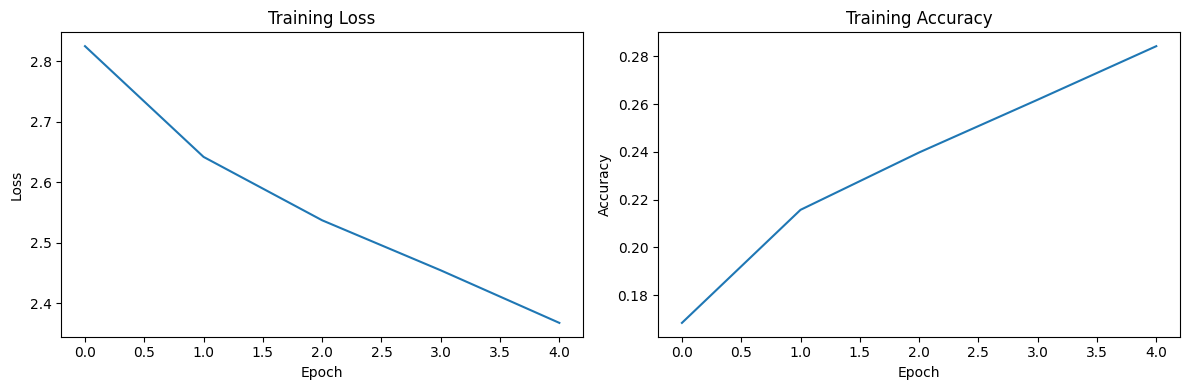

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(train_accuracies)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('basic_cnn_training.png')
plt.show()

## Training Curves — What Do These Graphs Mean?

### Training Loss (Left Graph)
Loss measures how wrong the model is. A loss of 0 would mean perfect predictions.
The graph shows loss dropping from 2.83 → 2.37 across 5 epochs, meaning the model 
is getting less wrong every time it sees the data. This is exactly what we want.

### Training Accuracy (Right Graph)
Accuracy measures how often the model guesses correctly.
The graph shows accuracy rising from 17% → 28% across 5 epochs, meaning the model 
is correctly identifying more skin conditions with each pass through the data.

### Why Both Graphs Matter Together
- Loss going **down** ✓
- Accuracy going **up** ✓

Both curves are still improving at epoch 5 and have not flattened out (plateaued).
This tells us the model is still learning and would continue to improve with more 
training time. With a GPU and 25 epochs, we would expect significantly better results.

# Baseline CNN — Summary & Findings

## What is a CNN?
A Convolutional Neural Network (CNN) is a type of deep learning model designed for image classification. 
Instead of looking at an entire image at once, it learns to detect patterns in small regions — starting 
with simple features like edges and colors, then building up to complex structures like textures and shapes. 
Each "convolutional block" in our model learns increasingly abstract representations of the skin image.

## Model Architecture
Our baseline CNN has 4 convolutional blocks followed by a classifier:
- **Block 1 (32 filters):** Detects basic edges and color patterns
- **Block 2 (64 filters):** Detects textures and gradients
- **Block 3 (128 filters):** Detects shapes and regional structures
- **Block 4 (256 filters):** Detects complex disease-specific visual patterns
- **Classifier:** Flattens the learned features and maps them to 23 skin disease categories

Each block uses:
- `Conv2d` — scans the image with learnable filters
- `BatchNorm` — stabilizes training by normalizing layer outputs
- `ReLU` — introduces non-linearity so the model can learn complex patterns
- `MaxPool` — reduces image size to keep computation manageable

## Computational Constraints
This model was trained on a **MacBook CPU**, which significantly limited our training configuration. 
The original configuration (224×224 images, 25 epochs) was estimated to take 2+ hours per notebook. 
To complete training in a reasonable timeframe, we reduced:
- **Image size:** 224×224 → 64×64
- **Epochs:** 25 → 5

## What is an Epoch?
One epoch means the model has seen every training image exactly once. With 5 epochs, the model passed 
through all 15,557 training images 5 times, adjusting its weights each time to reduce its prediction error.

## Results
| Metric | Score |
|--------|-------|
| Accuracy | 25.99% |
| F1 Score | 22.97% |
| Precision | 28.66% |
| Recall | 25.99% |

## What Do These Results Mean?
- **Random chance** with 23 classes would yield ~4.3% accuracy. Our model achieved 26%, meaning it 
  learned meaningful visual patterns from the data.
- **Best performing classes:** Nail Fungus (F1: 0.60) and Acne & Rosacea (F1: 0.43) — these likely 
  have visually distinct features that are easier to detect even at lower resolution.
- **Worst performing classes:** Bullous Disease and Poison Ivy scored 0.00 F1 — these classes have 
  fewer training samples, making them harder to learn from.
- The model shows **class imbalance issues** — it performs well on frequent classes and poorly on rare ones.

## Limitations
- Trained on CPU with reduced image size and epochs — not representative of full model potential
- Class imbalance across 23 categories affects performance on underrepresented conditions
- No regularization techniques applied — the model may be overfitting to training data
- 64×64 resolution loses fine-grained skin texture detail that may be diagnostically important

## Next Steps
This baseline establishes a performance benchmark. The following notebooks address its limitations:
- **Notebook 2 (Augmented CNN):** Applies random flips, rotations, and color jitter during training 
  to improve generalization across rare classes
- **Notebook 3 (Dropout CNN):** Adds dropout regularization to reduce overfitting and improve 
  performance on unseen data